# Examine Forest Age dataset from Besnard

https://datapub.gfz-potsdam.de/download/10.5880.GFZ.1.4.2023.006-VEnuo/2023-006_Besnard-et-al_Data-Description-v2.1.pdf

*Motivation*  
+ access dataset from https and read with xarray
+ clip to AOI
+ calc mean and std through the multiple 'members' (iterations) of the forest age dataset
+ write out a geotiff w/o re-grdding
+ wrap all above into a script (`tile_forestage.py`) that can run across all tiles 
+ Register and run as a `DPS` algorithm
+ `footprint` the tiles
+ DPS `run_build_stack` to get into tiles consistent with other boreal grids

  Contributors | Project | Affiliation | 
| ---------------- | ---------------- | ---------------- |
| Paul Montesano paul.m.montesano@nasa.gov |  multiple | NASA Goddard Space Flight Center |
| Jian Li | multiple |  NASA Goddard Space Flight Center |

In [2]:
pip install h5netcdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 896.1 kB/s eta 0:00:000:00:01
Note: you may need to restart the kernel to use updated packages.


In [44]:
import h5netcdf

In [45]:
import xarray as xr
import fsspec

In [46]:
import matplotlib.pyplot as plt

In [47]:
import sys
sys.path.append('/projects/code/icesat2_boreal/lib')

In [52]:
import rioxarray
import geopandas as gpd
from shapely.geometry import mapping
import requests

In [74]:
import numpy as np
import importlib
import tile_forestage
importlib.reload(tile_forestage)

<module 'tile_forestage' from '/projects/code/icesat2_boreal/lib/tile_forestage.py'>

### Test the script

In [3]:
cmd = f"/opt/conda/envs/python/bin/python /projects/code/icesat2_boreal/lib/tile_forestage.py -h"
!eval $cmd

usage: tile_forestage.py [-h] [-i IN_URL] [-v IN_VECTOR_FN] [-n IN_ID_NUM]
                         [-y YEAR] [--in_id_col IN_ID_COL] [-o OUTPUT_DIR]
                         [-tmp TMP_OUT_PATH] [--return_stack]

options:
  -h, --help            show this help message and exit
  -i IN_URL, --in_url IN_URL
                        The input of the forest age
  -v IN_VECTOR_FN, --in_vector_fn IN_VECTOR_FN
  -n IN_ID_NUM, --in_id_num IN_ID_NUM
                        The id number of an input vector tile that will define
                        the bounds for stack creation
  -y YEAR, --year YEAR  The year of the forest age data (2010, 2020)
  --in_id_col IN_ID_COL
                        The column of the tile layer name of the stack tiles
                        dataset that holds the tile num
  -o OUTPUT_DIR, --output_dir OUTPUT_DIR
                        The path for the output stack
  -tmp TMP_OUT_PATH, --tmp_out_path TMP_OUT_PATH
                        The tmp path for the output s

In [66]:
TILE_NUM = 4085

In [ ]:
%%time 
# Tile this dataset
URL = 'https://datapub.gfz-potsdam.de/download/10.5880.GFZ.1.4.2023.006-VEnuo/GAMIv2-1_2010-2020_100m.nc'

for CURRENT_TILE_NUM in [TILE_NUM, TILE_NUM-1, TILE_NUM+1]:
    
    args = f"--in_url {URL} --in_vector_fn /projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg \
            --in_id_num {CURRENT_TILE_NUM} --year 2020 --in_id_col tile_num --output_dir /projects/my-public-bucket/local_output/forest_age"
    
    cmd = f"/opt/conda/envs/python/bin/python /projects/code/icesat2_boreal/lib/tile_forestage.py {args}"
    !echo $cmd
    !eval $cmd

#### Run `tile_forestage` and return clipped xarray dataset

In [72]:
TILE_NUM = 3364
url

'https://datapub.gfz-potsdam.de/download/10.5880.GFZ.1.4.2023.006-VEnuo/GAMIv2-1_2010-2020_100m.nc'

In [75]:
%%time 
# This is actually a clipped DataArray
clipped_xr_dataset = tile_forestage.tile_forestage_(TILE_NUM, url, '/projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg', 'tile_num', VAR_NAME = "forest_age", YEAR = '2020', NODATA_VAL = np.nan, RETURN_STACK=True)

Opened the data: https://datapub.gfz-potsdam.de/download/10.5880.GFZ.1.4.2023.006-VEnuo/GAMIv2-1_2010-2020_100m.nc
Performing time selection and (for mem efficiency?) a general (bbox) geo-slice for forest_age with bound [-150.0, 65.0, -147.0, 66.0]...
Clipping to vector...


/opt/conda/envs/python/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Calcing ensemble mean and std...
Setting data of band mean_forest_age_ensemble that is less than 1.0 to nodata value of nan...
Setting data of band std_forest_age_ensemble that is less than 1.0 to nodata value of nan...
Writing the geotiff: /projects/my-public-bucket/local_output/forest_age/forestage_2020_0003364.tif...
Finished writing.
CPU times: user 25.9 s, sys: 12.7 s, total: 38.6 s
Wall time: 4min 1s


#### Plot the clipped xarray dataset
This shows that we have `nan` where we want `nodata` - I think this is okay for `build_stack` - but maybe that wont work and we need some valid value outside the dyanmic range of the data?

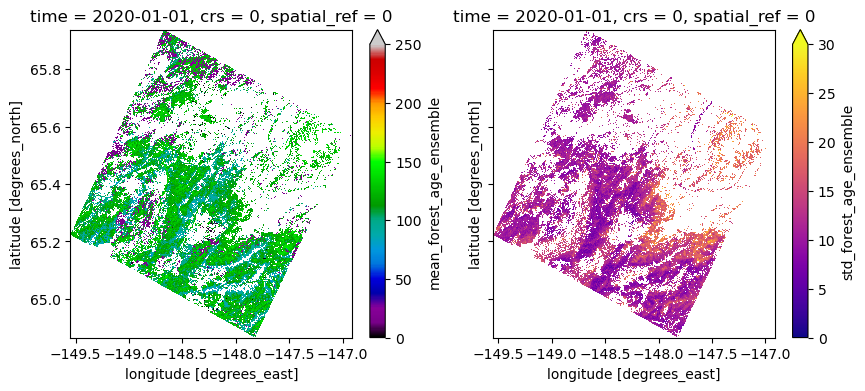

In [89]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10,4))
clipped_xr_dataset['mean_forest_age_ensemble'].plot(ax=axes[0], vmin=0, vmax=250, cmap = 'nipy_spectral', extend='max')
clipped_xr_dataset['std_forest_age_ensemble'].plot(ax=axes[1], vmin=0, vmax=30, cmap = 'plasma', extend='max')

### Build stacks using tiled forestage data

check `DPS_build_stack.ipynb` near top to see `build_stack` run examples on many different inputs we want to stack  

#### Here we can run `build_stack` on DPS output from `DPS_tile_forestage.ipynb` for which a tindex was run using `build_tindex.ipynb`

In [ ]:
# Besnard FOREST AGE 2020 - 
BUILD_STACK_DICT_FORESTAGE2020 = {
            'INDEX_URL': 'https://maap-ops-workspace.s3.amazonaws.com/shared/montesano/databank/boreal_tiles_v004.gpkg',
            'INDEX_FN': 'boreal_tiles_v004.gpkg',
            'ID_COL_NAME': 'tile_num',
            'TILE_NUM':TILE_NUM,
            'INDEX_LYR': 'boreal_tiles_v004',
            'COVAR_SRC_NAME': 'FORESTAGE_BES_2020',
            'BANDNAMES_LIST': 'mean_age_yr std_age_yr',
            'COVAR_TILE_URL': 'https://maap-ops-workspace.s3.amazonaws.com/shared/montesano/DPS_tile_lists/FORESTAGE100m/tile_forestage_v1/forestage_2020/FORESTAGE100m_tindex_master.gpkg', 
            'COVAR_TILE_FN':  '/projects/shared-buckets/montesano/DPS_tile_lists/FORESTAGE100m/tile_forestage_v1/forestage_2020/FORESTAGE100m_tindex_master.gpkg',
            'IN_COVAR_S3_COL': 's3_path',
            'OUTDIR': '/projects/my-public-bucket/local_output',
            'NODATA_VAL': -9999,
            'TILE_BUFFER_M': 0,
            'OUTPUT_CLIP_COG_FN':'',
            'CREDENTIALS_FN': None
        }

In [ ]:
BUILD_STACK_DICT = BUILD_STACK_DICT_FORESTAGE2020 

In [238]:
# INDEX clip shapes should be in equal area
# COVAR_TILE_FN tiles (of raster COGs) should be in 4326
args = f"\
    --in_tile_fn /projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg \
    --in_tile_id_col {BUILD_STACK_DICT['ID_COL_NAME']} \
    --in_tile_num {BUILD_STACK_DICT['TILE_NUM']} \
    --tile_buffer_m {BUILD_STACK_DICT['TILE_BUFFER_M']} \
    --in_tile_layer {BUILD_STACK_DICT['INDEX_LYR']} \
    -o {BUILD_STACK_DICT['OUTDIR']} \
    --covar_src_name {BUILD_STACK_DICT['COVAR_SRC_NAME']} \
    --bandnames_list {BUILD_STACK_DICT['BANDNAMES_LIST']} \
    --covar_tile_fn {BUILD_STACK_DICT['COVAR_TILE_FN']} \
    --in_covar_s3_col {BUILD_STACK_DICT['IN_COVAR_S3_COL']} \
    --input_nodata_value {BUILD_STACK_DICT['NODATA_VAL']}"

if 'dem' in BUILD_STACK_DICT['COVAR_TILE_FN']:
    args += " --shape 3000 --clip" # for topo
else:
    args += " --topo_off --shape 3000 --clip" # for not topo

print(args)

BUILD_STACK_DICT['BANDNAMES_LIST']


    --in_tile_fn /projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg     --in_tile_id_col tile_num     --in_tile_num 3359     --tile_buffer_m 0     --in_tile_layer boreal_tiles_v004     -o /projects/my-public-bucket/local_output     --covar_src_name FORESTAGE_BES_2020     --bandnames_list mean_age_yr std_age_yr     --covar_tile_fn /projects/shared-buckets/montesano/DPS_tile_lists/FORESTAGE100m/tile_forestage_v1/forestage_2020/FORESTAGE100m_tindex_master.gpkg     --in_covar_s3_col s3_path     --input_nodata_value -9999 --topo_off --shape 3000 --clip


'mean_age_yr std_age_yr'

In [239]:
!echo /opt/conda/envs/python/bin/python /projects/code/icesat2_boreal/lib/build_stack.py $args

/opt/conda/envs/python/bin/python /projects/code/icesat2_boreal/lib/build_stack.py --in_tile_fn /projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg --in_tile_id_col tile_num --in_tile_num 3359 --tile_buffer_m 0 --in_tile_layer boreal_tiles_v004 -o /projects/my-public-bucket/local_output --covar_src_name FORESTAGE_BES_2020 --bandnames_list mean_age_yr std_age_yr --covar_tile_fn /projects/shared-buckets/montesano/DPS_tile_lists/FORESTAGE100m/tile_forestage_v1/forestage_2020/FORESTAGE100m_tindex_master.gpkg --in_covar_s3_col s3_path --input_nodata_value -9999 --topo_off --shape 3000 --clip


In [240]:
!time /opt/conda/envs/python/bin/python /projects/code/icesat2_boreal/lib/build_stack.py $args 


---Running build_stack()---

6 covariate filename(s) intersecting the 0 m buffered bbox for tile id 3359:

Getting output height and width from input shape arg even though bbox is buffered (0 m) original tile geometry...
in_bbox: [908521.9999999953, 3123304.0000000093, 998521.9999999953, 3213304.0000000093]
3000 x 3000
Band indexes list: [1, 2]
['mean_age_yr', 'std_age_yr']
s3://maap-ops-workspace/montesano/dps_output/run_tile_forestage/tile_forestage_v1/forestage_2020/2025/01/24/09/18/54/909416/forestage_2020_0003360.tif
s3://maap-ops-workspace/montesano/dps_output/run_tile_forestage/tile_forestage_v1/forestage_2020/2025/01/24/09/19/19/388992/forestage_2020_0003358.tif
s3://maap-ops-workspace/montesano/dps_output/run_tile_forestage/tile_forestage_v1/forestage_2020/2025/01/24/09/20/00/560745/forestage_2020_0003359.tif
s3://maap-ops-workspace/montesano/dps_output/run_tile_forestage/tile_forestage_v1/forestage_2020/2025/01/24/09/21/10/074251/forestage_2020_0003265.tif
s3://maap-ops-work

# Dev work below

### Develop the steps to build a script to tile the forest age dataset

In [48]:
dirname = 'https://datapub.gfz-potsdam.de/download/10.5880.GFZ.1.4.2023.006-VEnuo'
bname = 'GAMIv2-1_2010-2020_class_fraction_0deg50.nc'
bname = 'GAMIv2-1_2010-2020_100m.nc'
url = f"{dirname}/{bname}"
url

'https://datapub.gfz-potsdam.de/download/10.5880.GFZ.1.4.2023.006-VEnuo/GAMIv2-1_2010-2020_100m.nc'

In [49]:
fs = fsspec.filesystem('http')

fsspec_caching = {
    "cache_type": "blockcache",  # block cache stores blocks of fixed size and uses eviction using a LRU strategy.
    "block_size": 8
    * 1024
    * 1024,  # size in bytes per block, adjust depends on the file size but the recommended size is in the MB
}

In [50]:
# %%time
# # Note that if we use a context, we'll close the file after the block so operations on xarray may fail if we don't load our data arrays.
# with fs.open(url, **fsspec_caching) as file:
#     ds = xr.open_dataset(file, engine="h5netcdf")

In [51]:
# %%time
# # Note that if we use a context, we'll close the file after the block so operations on xarray may fail if we don't load our data arrays.
# with fs.open(url) as file:
#     ds = xr.open_dataset(file)

### Subset to a BBOX
https://salem.readthedocs.io/en/latest/xarray_acc.html#subsetting-data

In [53]:
TILE_NUM = 110

In [54]:
boreal_tiles = gpd.read_file('/projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg')
boreal_tiles_sub = boreal_tiles[boreal_tiles.tile_num == TILE_NUM]

In [55]:
tile_bounds = [round(d, 0) for d in boreal_tiles_sub.to_crs(4326).total_bounds]
tile_bounds

[14.0, 63.0, 16.0, 64.0]

In [56]:
ds = xr.open_dataset(fs.open(url))

In [57]:
# This is a Dataset
ds

<xarray.Dataset> Size: 7TB
Dimensions:     (members: 20, latitude: 202500, longitude: 405000, time: 2)
Coordinates:
  * latitude    (latitude) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0
  * longitude   (longitude) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0
  * members     (members) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * time        (time) datetime64[ns] 16B 2010-01-01 2020-01-01
Data variables:
    forest_age  (members, latitude, longitude, time) int16 7TB ...
    crs         int64 8B ...
Attributes:
    product_name:   Global Age Mapping Integration (GAMI) v2.0
    version:        v2.1
    institution:    Helmholtz Center Potsdam GFZ German Research Centre for G...
    institute_id:   GFZ-Potsdam and MPI-BGC
    _FillValue:     -9999
    created_by:     Simon Besnard
    contact:        Simon Besnard (besnard@gfz-potsdam.de) and Nuno Carvalhai...
    references:     https://doi.org/10.5880/GFZ.1.4.2023.006 and https://doi....
    frequency:      2010 and 2020
    creation_date:  31-07-2024 09:59

In [58]:
%%time

ds_sub = ds["forest_age"].isel(members=0, time=1).sel(longitude=slice(tile_bounds[0], tile_bounds[2]), latitude=slice(tile_bounds[3], tile_bounds[1]))

CPU times: user 20.5 ms, sys: 5.5 ms, total: 26 ms
Wall time: 24.9 ms


In [59]:
# This is a DataArray
ds_sub

<xarray.DataArray 'forest_age' (latitude: 1125, longitude: 2250)> Size: 5MB
[2531250 values with dtype=int16]
Coordinates:
  * latitude   (latitude) float64 9kB 64.0 64.0 64.0 64.0 ... 63.0 63.0 63.0
  * longitude  (longitude) float64 18kB 14.0 14.0 14.0 14.0 ... 16.0 16.0 16.0
    members    int64 8B 0
    time       datetime64[ns] 8B 2020-01-01
Attributes:
    grid_mapping:  crs
    long_name:     'Forest age using a fusion machine learning and Landsat-ba...
    units:         years
    valid_max:     300
    valid_min:     1.0

### Masking is not working as expected

I have tried a few ways of doing this.  
When we write to geotiff, the nodata shows as 0 values...

In [60]:
ds_sub_test1 = ds_sub.where(ds_sub >= 1.0)

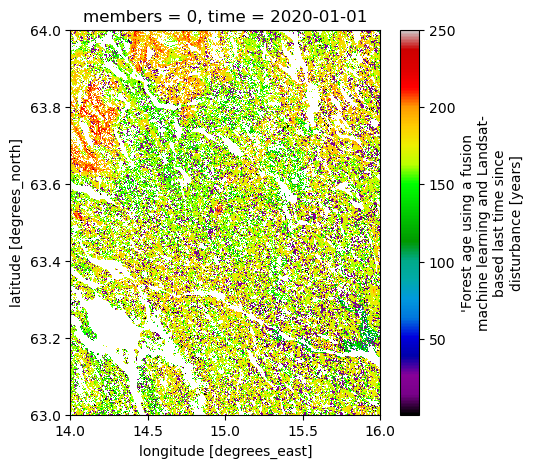

In [61]:
ds_sub_test1.plot(vmin=1, vmax=250, figsize=(5, 5), cmap = 'nipy_spectral')

In [62]:
ds_sub_test2 = ds_sub.where(ds_sub >= 0.0, ds_sub, -1.0) # this is good b/c -9999 value is not present in the data, but std can in theory be 0

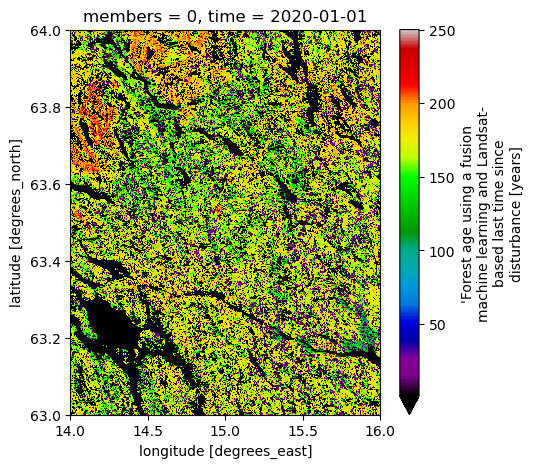

In [63]:
ds_sub_test2.plot(vmin=1, vmax=250, figsize=(5, 5), cmap = 'nipy_spectral')

In [64]:
ds_sub_test3 = ds_sub.where(ds_sub >= 1.0, ds_sub, 0) # 0 not good b/c in theory std can be 0

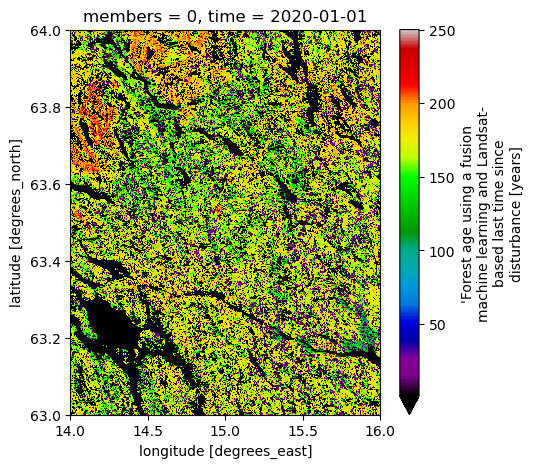

In [65]:
ds_sub_test3.plot(vmin=1, vmax=250, figsize=(5, 5), cmap = 'nipy_spectral')

In [65]:
import numpy as np

### Subset to an AOI
https://salem.readthedocs.io/en/latest/xarray_acc.html#subsetting-data

In [66]:
#xds = rioxarray.open_rasterio(url)
#xds = xds["forest_age"].isel(members=0, time=1)
#clipped = xds.rio.clip(boreal_tiles_sub.geometry.values, boreal_tiles_sub.crs)

In [99]:
mapping(boreal_tiles_sub.to_crs(4326).iloc[0].geometry)

{'type': 'Polygon',
 'coordinates': (((15.257044249360813, 62.73536582662125),
   (13.854427014141054, 63.234788683765565),
   (15.004794606480312, 63.85506319420587),
   (16.41703227733805, 63.34493077534049),
   (15.257044249360813, 62.73536582662125)),)}

In [109]:
ds_sub_rio = ds_sub.rio.write_crs("EPSG:4326")  # Replace EPSG code if necessary
clipped_ds = ds_sub_rio.rio.clip([mapping(boreal_tiles_sub.to_crs(4326).iloc[0].geometry)])

/opt/conda/envs/python/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [110]:
import numpy as np

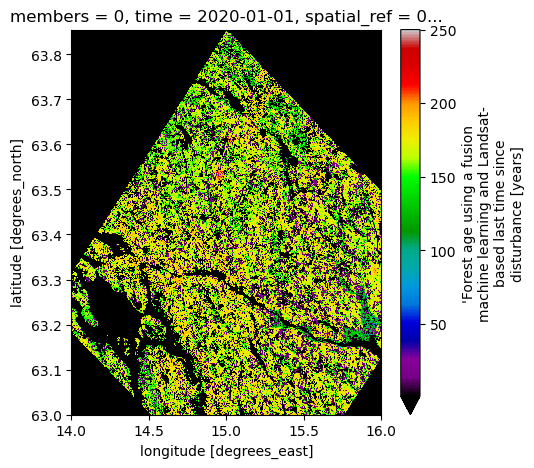

In [101]:
clipped_ds.plot(vmin=1, vmax=250, figsize=(5, 5), cmap = 'nipy_spectral')

### Take median of subset

In [70]:
# %%time 

# # Open the file as an xarray dataset
# with xr.open_dataset(fs.open(url)) as ds:

#     #ds = xr.open_dataset(fs.open(url))
#     #
#     ds_sub = ds["forest_age"].isel(time=1).sel(longitude = slice(tile_bounds[0]-1, tile_bounds[2]+1), latitude =  slice(tile_bounds[3]+1, tile_bounds[1]-1)).median(dim='members')

#     ds_sub_rio = ds_sub.rio.write_crs("EPSG:4326")  # Replace EPSG code if necessary
#     clipped_ds = ds_sub_rio.rio.clip([mapping(boreal_tiles_sub.to_crs(4326).iloc[0].geometry)])
#     clipped_ds.plot(vmin=1, vmax=250, figsize=(5, 5), cmap = 'nipy_spectral')

In [71]:
# from multiprocessing import Pool
# from functools import partial

# # Clip and plot
# def clip_to_tile(ds, boreal_tiles_sub):
    
#     # Assign spatial reference and enable rioxarray for geospatial operations
#     ds = ds.rio.write_crs("EPSG:4326")  # Replace EPSG code if necessary
    
#     # Step : Clip the dataset to the polygon
#     clipped_ds = ds.rio.clip([mapping(boreal_tiles_sub.to_crs(4326).iloc[0].geometry)])
#     clipped_ds = clipped_ds.where(clipped_ds >= 1.) 

#     return clipped_ds

# def process_ds(ds, tile_bounds, tiles_gdf_sub, MEMBER_NUM):
#     ds_sub = ds["forest_age"].isel(members=MEMBER_NUM, time=1).sel(longitude = slice(tile_bounds[0]-1, tile_bounds[2]+1), 
#                                                               latitude =  slice(tile_bounds[3]+1, tile_bounds[1]-1))

#     clipped_ds = clip_to_tile(ds_sub, tiles_gdf_sub)
    
#     return clipped_ds

# def process_ds_all(ds, tile_bounds, tiles_gdf_sub, TIME_IDX=1, VAR_NAME="forest_age"):
    
#     ds_sub = ds[VAR_NAME].isel(time=TIME_IDX).sel(longitude = slice(tile_bounds[0]-1, tile_bounds[2]+1), 
#                                                               latitude =  slice(tile_bounds[3]+1, tile_bounds[1]-1))

#     clipped_ds = clip_to_tile(ds_sub, tiles_gdf_sub)
    
#     return clipped_ds

# def tile_standage(TILE_NUM, 
#                       URL = 'https://datapub.gfz-potsdam.de/download/10.5880.GFZ.1.4.2023.006-VEnuo/GAMIv2-1_2010-2020_100m.nc',
#                       TILES_FN = '/projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg',
#                       ID_COL = 'tile_num',
#                       VAR_NAME = "forest_age",
#                       YEAR = '2020',
#                       OUTDIR = '/projects/my-public-bucket/local_output/forest_age',
#                       RETURN_STACK=False):
    
#     '''Given an ensemble standage dataset and vector , clip to a tile, calc mean and std layers, stack, and output a geotiff 
#     '''
    
#     tiles_gdf = gpd.read_file(TILES_FN)
#     tiles_gdf_sub = tiles_gdf[tiles_gdf[ID_COL] == TILE_NUM]
#     tile_bounds = [round(d, 0) for d in tiles_gdf_sub.to_crs(4326).total_bounds]

#     TIME_IDX = 0
#     if YEAR == '2020': TIME_IDX = 1

#     with xr.open_dataset(fs.open(url)) as ds:

#         clipped_ds = process_ds_all(ds, tile_bounds, tiles_gdf_sub, TIME_IDX=TIME_IDX, VAR_NAME=VAR_NAME)
#         out_stack = xr.concat([clipped_ds_list.mean(dim='members'), clipped_ds_list.std(dim='members')], 
#                               dim = 'time', compat="no_conflicts").rio.write_crs("EPSG:4326") 

#         # write stack
#         out_stack_fn = os.path.join(OUTDIR, f"{VAR_NAME.replace('_','')}_2020_{int(TILE_NUM):07}.tif")
#         out_stack.rio.to_raster(out_stack_fn , tiled=True)
        
#         if RETURN_STACK:
#             return out_stack
#         else:
#             return out_stack_fn

In [ ]:
def get_stand_age_list(URL, TILE_NUM, TILES_FN = '/projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg'):
    
    tiles_gdf = gpd.read_file(TILES_FN)
    tiles_gdf_sub = tiles_gdf[tiles_gdf.tile_num == TILE_NUM]
    tile_bounds = [round(d, 0) for d in tiles_gdf_sub.to_crs(4326).total_bounds]

    with xr.open_dataset(fs.open(url)) as ds:

        # def wrapper_process_ds(MEMBER_NUM, DS=ds, TILE_BOUNDS=tile_bounds, TILES_GDF_SUB=tiles_gdf_sub):
        #     return process_ds(DS, TILE_BOUNDS, TILES_GDF_SUB, MEMBER_NUM)

        # with Pool(processes=10) as pool:
        #    clipped_ds_list = pool.map(partial(wrapper_process_ds), [0,1,2,3,4,5,6,7,8,9])
    
        #clipped_ds_list = [process_ds(ds, tile_bounds, tiles_gdf_sub, MEMBER_NUM) for MEMBER_NUM in list(range(0,20))]

        clipped_ds_list = process_ds_all(ds, tile_bounds, tiles_gdf_sub)

        return clipped_ds_list

### Clip all 'member' layers of `forest_age` and return as a list

In [72]:
TILE_NUM = 3364
url

'https://datapub.gfz-potsdam.de/download/10.5880.GFZ.1.4.2023.006-VEnuo/GAMIv2-1_2010-2020_100m.nc'

In [75]:
%%time 
# This is actually a clipped DataArray
#clipped_array = get_stand_age_list(url, TILE_NUM)
clipped_array = tile_forestage.tile_forestage_(TILE_NUM, url, '/projects/shared-buckets/montesano/databank/boreal_tiles_v004.gpkg', 'tile_num', VAR_NAME = "forest_age", YEAR = '2020', NODATA_VAL = np.nan, RETURN_STACK=True)

Opened the data: https://datapub.gfz-potsdam.de/download/10.5880.GFZ.1.4.2023.006-VEnuo/GAMIv2-1_2010-2020_100m.nc
Performing time selection and (for mem efficiency?) a general (bbox) geo-slice for forest_age with bound [-150.0, 65.0, -147.0, 66.0]...
Clipping to vector...


/opt/conda/envs/python/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Calcing ensemble mean and std...
Setting data of band mean_forest_age_ensemble that is less than 1.0 to nodata value of nan...
Setting data of band std_forest_age_ensemble that is less than 1.0 to nodata value of nan...
Writing the geotiff: /projects/my-public-bucket/local_output/forest_age/forestage_2020_0003364.tif...
Finished writing.
CPU times: user 25.9 s, sys: 12.7 s, total: 38.6 s
Wall time: 4min 1s


### Need to change how geotiff is written so nodata is handled as expected in build_stack?

### Maybe check mosaic_reader() 'as_masked'?
https://github.com/cogeotiff/rio-tiler/blob/main/docs/src/examples/Using-rio-tiler.ipynb

In [76]:
import morecantile
from matplotlib.pyplot import imshow, plot, subplots

from rio_tiler.io import Reader
from rio_tiler.models import ImageData

In [77]:
src_path = '/projects/my-public-bucket/local_output/forest_age/forestage_2020_0003364.tif'

In [78]:
# As for Rasterio, using context manager is a good way to
# make sure the dataset are closed when we exit.
with Reader(src_path) as src:
    print("rasterio dataset:")
    print(src.dataset)
    print()
    print("metadata from rasterio:")
    print(src.dataset.meta)
    print()
    # Using rio-tiler Info() method
    info = src.info()
    print("rio-tiler dataset info:")
    print(src.info().json(exclude_none=True))

print(src.dataset.closed)

rasterio dataset:
<open DatasetReader name='/projects/my-public-bucket/local_output/forest_age/forestage_2020_0003364.tif' mode='r'>

metadata from rasterio:
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 2968, 'height': 1207, 'count': 2, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.0008888888888888927, 0.0, -149.54844444444444,
       0.0, -0.0008888888888888794, 65.93777777777777)}

rio-tiler dataset info:
{"bounds":[-149.54844444444444,64.86488888888888,-146.91022222222222,65.93777777777777],"minzoom":6,"maxzoom":10,"band_metadata":[["b1",{}],["b2",{}]],"band_descriptions":[["b1","mean_forest_age_ensemble"],["b2","std_forest_age_ensemble"]],"dtype":"float64","nodata_type":"None","colorinterp":["gray","undefined"],"scales":[1.0,1.0],"offsets":[0.0,0.0],"driver":"GTiff","count":2,"width":2968,"height":1207,"overviews":[]}
True


/opt/conda/envs/python/lib/python3.10/site-packages/rio_tiler/io/rasterio.py:130: NoOverviewWarning: The dataset has no Overviews. rio-tiler performances might be impacted.
  warnings.warn(


In [79]:
with Reader(src_path) as src:
    meta = src.statistics(max_size=256)

    assert isinstance(meta, dict)
    print(list(meta))
    print(meta["b1"].model_dump())

['b1', 'b2']
{'min': 1.0, 'max': 146.0, 'mean': 101.57326517150398, 'count': 7580.0, 'sum': 769925.3500000001, 'std': 33.89420320899177, 'median': 111.95, 'majority': 20.0, 'minority': 7.0, 'unique': 1193.0, 'histogram': [[261, 652, 0, 1, 9, 229, 1242, 2277, 2453, 456], [1.0, 15.5, 30.0, 44.5, 59.0, 73.5, 88.0, 102.5, 117.0, 131.5, 146.0]], 'valid_percent': 28.2, 'masked_pixels': 19300.0, 'valid_pixels': 7580.0, 'percentile_2': 14.0, 'percentile_98': 135.85}


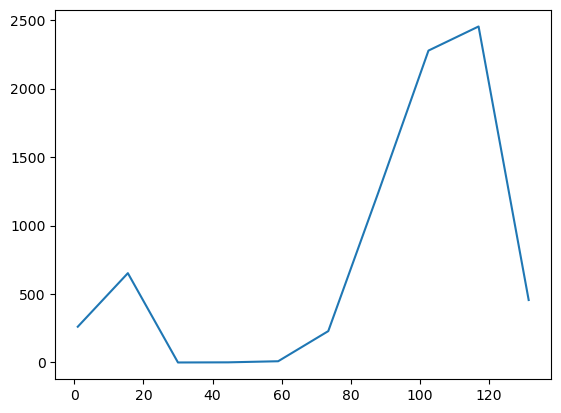

In [80]:
# Band 1
plot(meta["b1"].histogram[1][0:-1], meta["b1"].histogram[0])

In [81]:
with Reader(src_path) as src:
    # By default `preview()` will return an array with its longest dimension lower or equal to 1024px
    data = src.preview()
    print(data.data.shape)
    assert isinstance(data, ImageData)

(2, 417, 1024)


In [82]:
print(f"width: {data.width}")
print(f"height: {data.height}")
print(f"bands: {data.count}")
print(f"crs: {data.crs}")
print(f"bounds: {data.bounds}")
print(f"metadata: {data.metadata}")
print(f"assets: {data.assets}")
print(f"dataset stats: {data.dataset_statistics}")  # If stored in the original dataset

print(type(data.data))
print(type(data.mask))

width: 1024
height: 417
bands: 2
crs: EPSG:4326
bounds: BoundingBox(left=-149.54844444444444, bottom=64.86488888888888, right=-146.91022222222222, top=65.93777777777777)
metadata: {'AREA_OR_POINT': 'Area'}
assets: ['/projects/my-public-bucket/local_output/forest_age/forestage_2020_0003364.tif']
dataset stats: None
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [83]:
print((data.data))
print((data.mask))

[[[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]]
[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


In [146]:
data.array

masked_array(
  data=[[[-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         ...,
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0]],

        [[-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         ...,
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0],
         [-9999.0, -9999.0, -9999.0, ..., -9999.0, -9999.0, -9999.0]]],
  mask=[[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]

In [85]:
# Rasterio doesn't use the same axis order than visualization libraries (e.g matplotlib, PIL)
# in order to display the data we need to change the order (using rasterio.plot.array_to_image).
# the ImageData class wraps the rasterio function in the `data_as_image()` method.
print(type(data))
print(data.data.shape)

image = data.data_as_image()
# data_as_image() returns a numpy.ndarray
print(type(image))
print(image.shape)

#imshow(image)

<class 'rio_tiler.models.ImageData'>
(2, 417, 1024)
<class 'numpy.ma.core.MaskedArray'>
(417, 1024, 2)


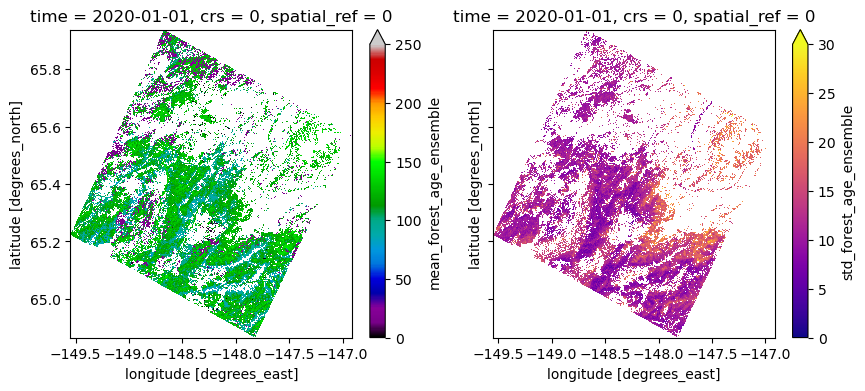

In [86]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10,4))
clipped_array[ 'mean_forest_age_ensemble'].plot(ax=axes[0], vmin=0, vmax=250, cmap = 'nipy_spectral', extend='max')
clipped_array[ 'std_forest_age_ensemble'].plot(ax=axes[1], vmin=0, vmax=30, cmap = 'plasma', extend='max')

In [87]:
clipped_array[ 'mean_forest_age_ensemble']

<xarray.DataArray 'mean_forest_age_ensemble' (latitude: 1207, longitude: 2968)> Size: 29MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * latitude     (latitude) float64 10kB 65.94 65.94 65.94 ... 64.87 64.87 64.87
  * longitude    (longitude) float64 24kB -149.5 -149.5 -149.5 ... -146.9 -146.9
    time         datetime64[ns] 8B 2020-01-01
    crs          int64 8B 0
    spatial_ref  int64 8B 0

In [ ]:
# Test convert to Dataset and add bandnames, write to geotiff and check
# Turn this DataArray into a Dataset so you can add bandnames
clipped_dataset = xr.Dataset()
bandnames_list = ['mean_forest_age_ensemble','std_forest_age_ensemble']

for i, band in enumerate(bandnames_list):

    clipped_dataset[band] = clipped_array[i]

# # write stack
# out_stack_fn = os.path.join('/projects/my-public-bucket/local_output/forest_age', f"forestage_2020_{int(TILE_NUM):07}_TEST.tif")
# print(f'Writing the geotiff: {out_stack_fn}...')
# clipped_dataset.rio.to_raster(out_stack_fn , tiled=True)
# print(f'Finished writing.')

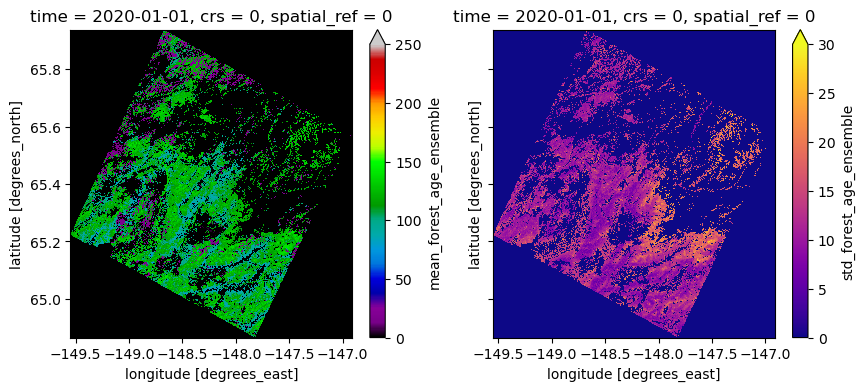

In [69]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10,4))
clipped_dataset['mean_forest_age_ensemble'].plot(ax=axes[0], vmin=0, vmax=250, cmap = 'nipy_spectral', extend='max')
clipped_dataset['std_forest_age_ensemble'].plot(ax=axes[1], vmin=0, vmax=30, cmap = 'plasma', extend='max')

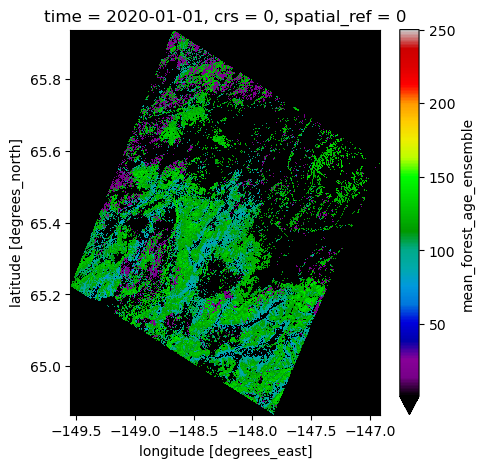

In [116]:
nodata_value = np.nan
da_test = clipped_dataset['mean_forest_age_ensemble'].where(clipped_dataset['mean_forest_age_ensemble'] > 0, other=-9999)
da_test.plot(vmin=1, vmax=250, figsize=(5, 5), cmap = 'nipy_spectral')

In [117]:
da_test

<xarray.DataArray 'mean_forest_age_ensemble' (latitude: 1207, longitude: 2968)> Size: 29MB
array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       ...,
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.]])
Coordinates:
  * latitude     (latitude) float64 10kB 65.94 65.94 65.94 ... 64.87 64.87 64.87
  * longitude    (longitude) float64 24kB -149.5 -149.5 -149.5 ... -146.9 -146.9
    time         datetime64[ns] 8B 2020-01-01
    crs          int64 8B 0
    spatial_ref  int64 8B 0

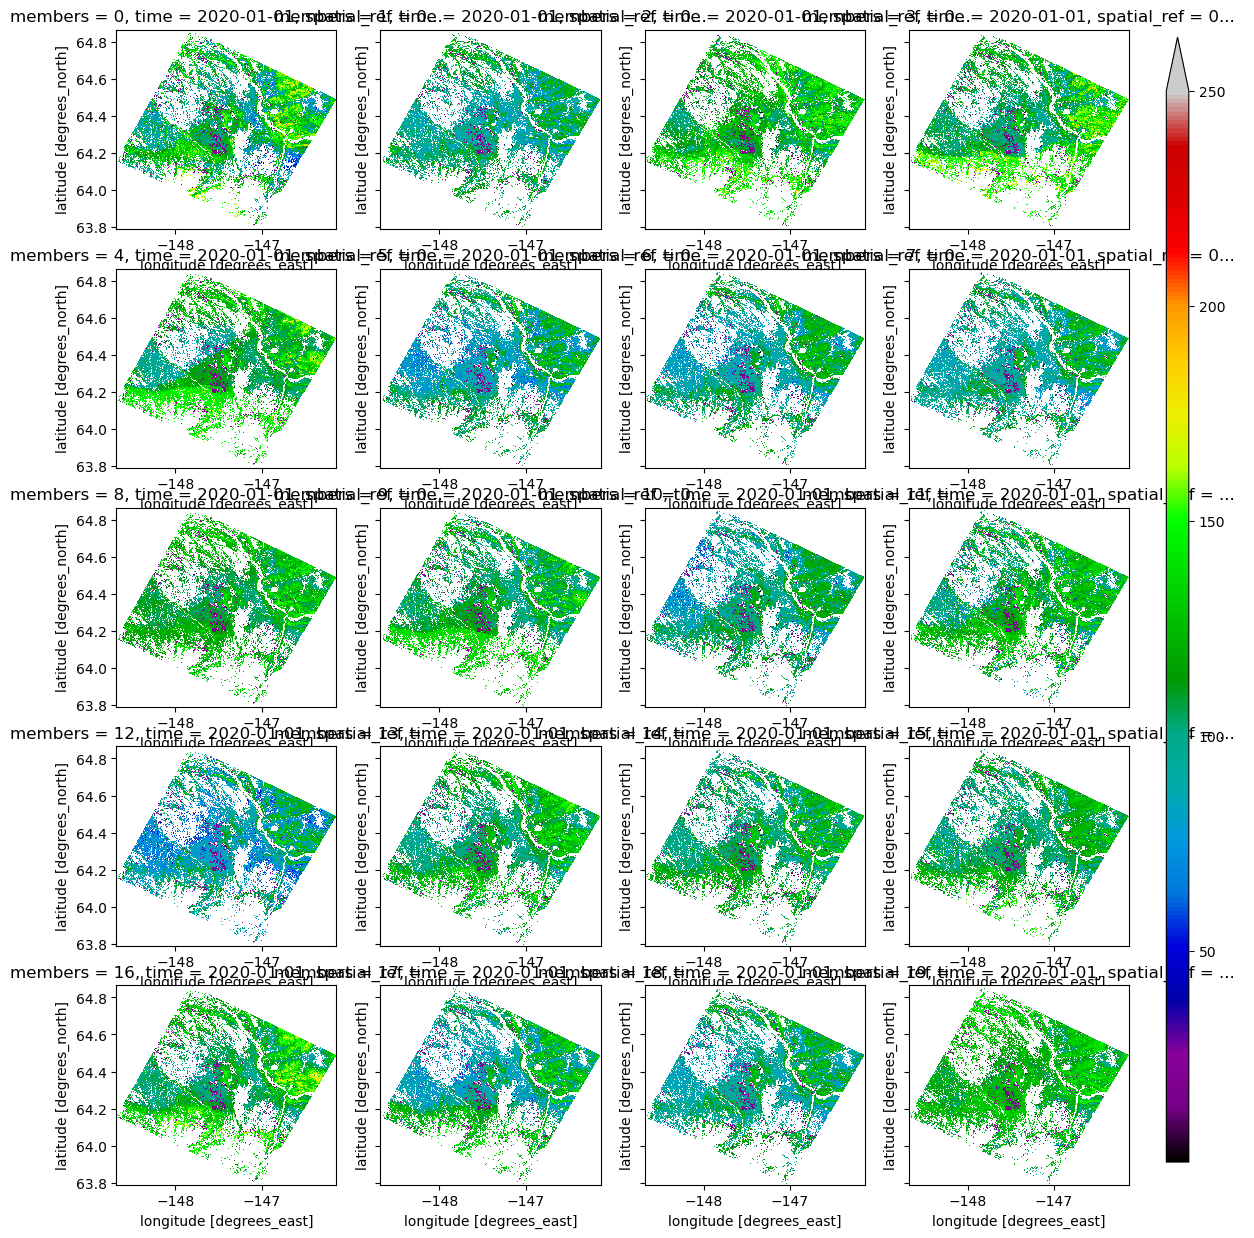

In [162]:
# fig, axes = plt.subplots(nrows=5, ncols=4, sharey=True, figsize=(15,15))

# for i, ax in enumerate(axes.ravel()):
#     im = clipped_array[i].plot(ax=ax, cmap='nipy_spectral', vmin=1, vmax=250, add_colorbar=False)

# fig.subplots_adjust(right=0.8)
# cbar_ax = fig.add_axes([0.825, 0.125, 0.015, 0.75])
# fig.colorbar(im, cax=cbar_ax, extend='max', label=' ')
# plt.show()

### Concat `forest_age` list into a stack

In [168]:
# ds_stack = xr.concat(clipped_ds_list, dim = 'members', compat="no_conflicts")
# ds_mean = clipped_ds_list.mean(dim='members')
# ds_std = clipped_ds_list.std(dim='members')

/opt/conda/envs/python/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### Compute mean, std `forest_age` through stack

In [164]:
# ds_mean = ds_stack.mean(dim='members')
# ds_std = ds_stack.std(dim='members')

/opt/conda/envs/python/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


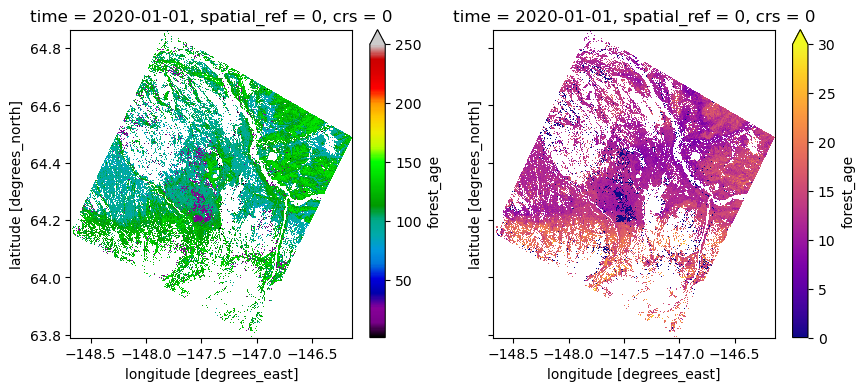

In [169]:
# fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10,4))
# ds_mean.plot(ax=axes[0], vmin=1, vmax=250, cmap = 'nipy_spectral', extend='max')
# ds_std.plot(ax=axes[1], vmin=0, vmax=30, cmap = 'plasma', extend='max')

### Process multiple tiles

In [172]:
list(range(100,110))

[100, 101, 102, 103, 104, 105, 106, 107, 108, 109]

In [178]:
import multiprocessing

In [ ]:
%%time

# Create a pool of workers
with multiprocessing.Pool(processes=10) as pool:
    # Map the function to the inputs
    out_stack_list = pool.map(tile_standage, list(range(100,110)))